
Linear Regression
MAE: 0.004936263287812283
RMSE: 0.005763997037116312
R2: 0.9979467108610909


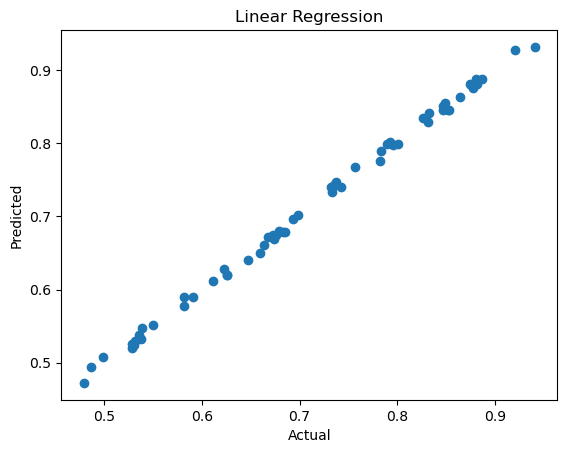


Random Forest
MAE: 0.008851166666666741
RMSE: 0.011744879664489274
R2: 0.9914748946408746


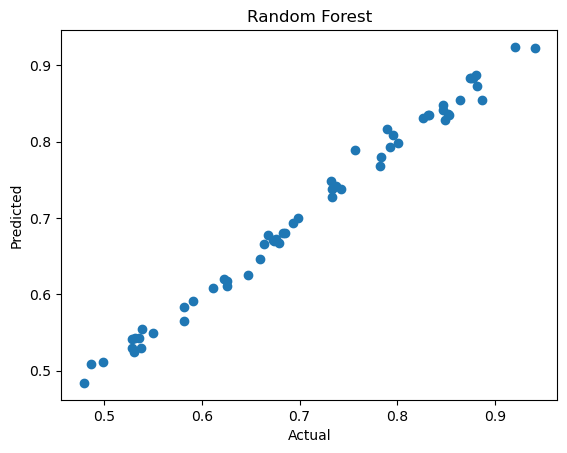


SVM
MAE: 0.07484942997885131
RMSE: 0.08501099923990138
R2: 0.5533648960151204


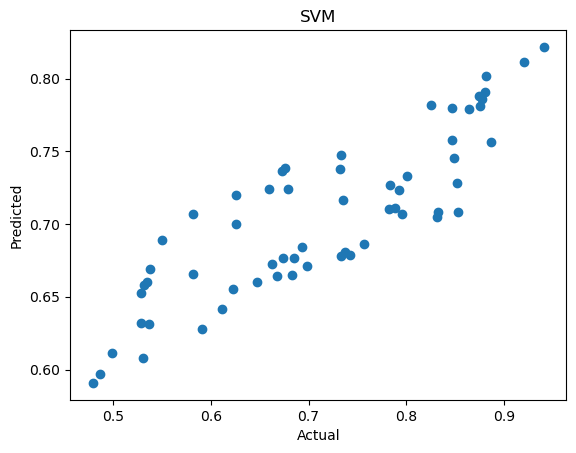


Final Comparison:
Linear Regression -> MAE: 0.004936263287812283 RMSE: 0.005763997037116312 R2: 0.9979467108610909
Random Forest -> MAE: 0.008851166666666741 RMSE: 0.011744879664489274 R2: 0.9914748946408746
SVM -> MAE: 0.07484942997885131 RMSE: 0.08501099923990138 R2: 0.5533648960151204


In [3]:
import pandas as pd
import numpy as np

# ML models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plot
import matplotlib.pyplot as plt


data = pd.read_csv("IIT_B_Dataset_300.csv")

# Inputs (features)
X = data[['Feed_Benzene', 'Reflux', 'Stages', 'Feed_Stage']]

# Outputs (target) → we will predict xD first
y = data['xD']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(),
    "SVM": SVR()
}

results = {}


for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = [mae, rmse, r2]

    print(f"\n{name}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)

    # Plot
    plt.scatter(y_test, y_pred)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(name)
    plt.show()

print("\nFinal Comparison:")
for model, values in results.items():
    print(model, "-> MAE:", values[0], "RMSE:", values[1], "R2:", values[2])